# Drone Swarm Formation Assignment — Model Benchmark

Evaluates all models on in-distribution test scenarios matching the training data distribution.

**Models:** SuperGlue + DecentAuction · SuperGlue alone · DecentAuction (Gossip) · HungarianImitator · Hungarian optimal

## 1. Configuration

In [1]:
import sys, os

# ── Point this at the folder containing your .py files ──────────────────────
CODE_DIR = "."
sys.path.insert(0, CODE_DIR)

# ── Checkpoint paths (set to None to skip loading) ──────────────────────────
CKPT_SUPER_DECENT = "model/super_decent_auction_best_new_v4.pt"   # SuperGlue + DecentAuction
CKPT_DECENT       = "model/decent_auction_best.pt"                # DecentAuction (Gossip GNN)
CKPT_SUPERGLUE    = "model/superglue_negotiator_best_new_v4.pt"   # SuperGlue alone
CKPT_HUNGARIAN    = "model/hungarian_imitator_best.pt"            # HungarianImitator

# ── Evaluation settings ──────────────────────────────────────────────────────
N_SCENARIOS   = 200
SWARM_SIZES   = [8, 12, 16, 20]
SEED          = 42

# ── Visualisation ────────────────────────────────────────────────────────────
VIZ_SCENARIO_IDX = 0
CUSTOM_N         = 12
CUSTOM_FORMATION = "Circle"   # A | V | W | Circle | Rectangle | Triangle
CUSTOM_SEED      = 7

print("Configuration loaded.")


Configuration loaded.


## 2. Imports

In [2]:
import random
import math
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd
from scipy.optimize import linear_sum_assignment
from torch_geometric.data import Data

# ── Project modules ──────────────────────────────────────────────────────────
from local_negotiator_v2 import (
    LocalNegotiatorGNN,
    assignment_quality_metrics,
    build_candidate_mask,
    build_comm_graph,
    build_candidate_edges,
    build_candidate_edge_attr,
    build_node_features,
    COMM_RADIUS,
    SLOT_VISIBILITY_RADIUS,
    NUM_FORMATIONS,
    hungarian_assignment,
    load_negotiator_dataset,
    prepare_dataset,
    sample_to_pyg,
)
from decent_auction import (
    DecentAuctionModel,
    evaluate_decent_auction,
    DECENT_AUCTION_ROUNDS,
)
from superglue_negotiator_new import (
    SuperGlueSwarmMatcher,
    evaluate_superglue_matcher,
    sinkhorn_round_assignment,
)
from super_decent_auction_new import (
    SuperDecentAuctionModel,
    evaluate_super_decent_auction,
)
from hungarian_imitator_v2 import (
    HungarianImitator,
    evaluate_hungarian_imitator,
    greedy_bijection_assignment,
)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## 3. Scenario Generator

> **Fixed:** uses the same coordinate system and formation geometry as training data (`[0, 10]` arena, `_enforce_min_sep`, random rotation + offset). The original notebook used `[-span, span]` coordinates which caused near-random model outputs.

In [3]:
# ── Cell 6 · Scenario generator (matches training distribution exactly) ───────
#
# KEY FIX: The training data (make_sample in drone_swarm_datagen.ipynb) does:
#   slots = slots_rel + cog          ← no rotation, no random offset
#   drone_pos ~ uniform[0, 10]       ← full arena spread
#   n ~ uniform int in [N_MIN, N_MAX] = [8, 20]   ← all sizes, not just 4
#
# Adding rotation or a large offset shifts slots away from drones, creating
# drone→slot distances > SLOT_VISIBILITY_RADIUS (5.0 m) that the model never
# saw during training. That degrades bij from 0.985 → 0.79.
# This fixed version replicates make_sample exactly.

FORMATION_NAMES = ["A", "V", "W", "Circle", "Rectangle", "Triangle"]
ARENA_SIZE   = 10.0
N_MIN, N_MAX = 8, 20          # full training range
MIN_SLOT_SEP = 0.30


def _enforce_min_sep(pts, min_sep=MIN_SLOT_SEP):
    if len(pts) < 2:
        return pts
    seen = {}
    for i, p in enumerate(pts):
        key = (round(float(p[0]), 6), round(float(p[1]), 6))
        if key in seen:
            pts[i] += np.random.uniform(-1e-3, 1e-3, size=2)
        else:
            seen[key] = i
    diff  = pts[:, None, :] - pts[None, :, :]
    dists = np.linalg.norm(diff, axis=-1)
    np.fill_diagonal(dists, np.inf)
    min_d = dists.min()
    if 0 < min_d < min_sep:
        pts = pts * (min_sep / min_d)
    return pts


# Formation generators copied verbatim from drone_swarm_datagen.ipynb
def _linspace_seg(a, b, n, include_end=False):
    total = n if include_end else n
    pts = []
    for i in range(total):
        t = i / max(n - 1 if include_end else n, 1)
        pts.append(a + t * (b - a))
    return pts

def gen_A(n):
    apex       = np.array([0.0,  1.0])
    left_base  = np.array([-1.2, -1.0])
    right_base = np.array([ 1.2, -1.0])
    n_leg   = max(3, int(n * 0.65))
    n_cross = max(2, n - n_leg)
    n_left  = n_leg // 2
    n_right = n_leg - n_left
    pts = []
    for i in range(n_left):
        t = i / n_left
        pts.append(left_base + t * (apex - left_base))
    for i in range(n_right):
        t = i / n_right
        pts.append(apex + t * (right_base - apex))
    frac = 0.45
    cl = left_base  + frac * (apex - left_base)
    cr = right_base + frac * (apex - right_base)
    for i in range(n_cross):
        t = i / max(n_cross - 1, 1)
        pts.append(cl + t * (cr - cl))
    pts = np.array(pts[:n], dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts)

def gen_V(n):
    apex      = np.array([0.0,  -1.0])
    left_tip  = np.array([-1.8,  1.0])
    right_tip = np.array([ 1.8,  1.0])
    n_left  = n // 2
    n_right = n - n_left
    pts = []
    for i in range(n_left):
        t = i / max(n_left - 1, 1)
        pts.append(apex + t * (left_tip - apex))
    for i in range(1, n_right + 1):
        t = i / n_right
        pts.append(apex + t * (right_tip - apex))
    pts = np.array(pts[:n], dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts)

def gen_W(n):
    tops    = [np.array([-2.0, 1.0]), np.array([0.0, 1.0]), np.array([2.0, 1.0])]
    valleys = [np.array([-1.0, -1.0]), np.array([1.0, -1.0])]
    segs = [(tops[0], valleys[0]), (valleys[0], tops[1]),
            (tops[1], valleys[1]), (valleys[1], tops[2])]
    n_per = max(2, n // 4)
    extra = n - n_per * 4
    pts = []
    for s, (a, b) in enumerate(segs):
        cnt = n_per + (1 if s < extra else 0)
        for i in range(cnt):
            t = i / cnt
            pts.append(a + t * (b - a))
    pts = np.array(pts[:n], dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts)

def gen_O(n):
    angles = np.linspace(0, 2 * math.pi, n, endpoint=False)
    pts    = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    pts   -= pts.mean(axis=0)
    return _enforce_min_sep(pts)

def gen_Rectangle(n):
    w, h  = 2.0, 1.0
    perim = 2 * (w + h)
    ts    = np.linspace(0, perim, n, endpoint=False)
    pts   = []
    for t in ts:
        if t < w:             pts.append([-w/2 + t, -h/2])
        elif t < w + h:       pts.append([w/2, -h/2 + (t - w)])
        elif t < 2*w + h:     pts.append([w/2 - (t - w - h), h/2])
        else:                 pts.append([-w/2, h/2 - (t - 2*w - h)])
    pts = np.array(pts, dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts)

def gen_Triangle(n):
    v0 = np.array([0.0,  math.sqrt(3)/2 * 2/3])
    v1 = np.array([-1.0, -math.sqrt(3)/2 * 1/3])
    v2 = np.array([ 1.0, -math.sqrt(3)/2 * 1/3])
    sides = [(v0, v1), (v1, v2), (v2, v0)]
    n_side = n // 3
    extras = n - n_side * 3
    pts = []
    for idx, (a, b) in enumerate(sides):
        cnt = n_side + (1 if idx < extras else 0)
        for i in range(cnt):
            t = i / max(cnt, 1)
            pts.append(a + t * (b - a))
    pts = np.array(pts[:n], dtype=np.float64)
    pts -= pts.mean(axis=0)
    return _enforce_min_sep(pts)

# Map formation names to generators (Circle == O)
FORMATION_GENERATORS = {
    "A": gen_A, "V": gen_V, "W": gen_W,
    "Circle": gen_O, "Rectangle": gen_Rectangle, "Triangle": gen_Triangle,
}


def generate_scenario(
    n: int,
    formation_name=None,
    rng=None,
) -> Data:
    """
    Replicate make_sample() from drone_swarm_datagen.ipynb exactly:
      - drone_pos ~ uniform[0, 10]²  (no noise, no clip — same as training)
      - slots = slots_rel + CoG       (no rotation, no random offset)
      - y via Hungarian
    This ensures the candidate_mask sparsity and edge_attr distribution
    match what the model was trained on.
    """
    if rng is None:
        rng = np.random.default_rng()
    if formation_name is None:
        formation_name = rng.choice(FORMATION_NAMES)

    fid = FORMATION_NAMES.index(formation_name)
    gen = FORMATION_GENERATORS[formation_name]

    # ── Drone positions: exactly as in training ──────────────────────────────
    drone_pos = rng.uniform(0, ARENA_SIZE, size=(n, 2)).astype(np.float32)
    cog       = drone_pos.mean(axis=0)

    # ── Formation slots: centred at CoG, NO rotation, NO offset ─────────────
    slots_rel = gen(n).astype(np.float32)
    slots     = slots_rel + cog

    # ── Hungarian ground truth ───────────────────────────────────────────────
    cost             = np.linalg.norm(drone_pos[:, None, :] - slots[None, :, :], axis=-1)
    row, col         = linear_sum_assignment(cost)
    y                = np.empty(n, dtype=np.int64)
    y[row]           = col

    return Data(
        drone_pos      = torch.tensor(drone_pos, dtype=torch.float32),
        slots          = torch.tensor(slots,     dtype=torch.float32),
        y              = torch.tensor(y,         dtype=torch.long),
        formation_id   = torch.tensor(fid,       dtype=torch.long),
        formation_name = formation_name,
        n_drones       = n,
    )


def generate_dataset(n_scenarios, seed=SEED):
    """Stratified sample across all sizes [N_MIN, N_MAX] and all 6 formations."""
    rng = np.random.default_rng(seed)
    samples = []
    for _ in range(n_scenarios):
        n    = int(rng.integers(N_MIN, N_MAX + 1))
        name = rng.choice(FORMATION_NAMES)
        samples.append(generate_scenario(n, formation_name=name, rng=rng))
    return samples


dataset = generate_dataset(N_SCENARIOS)
print(f"Generated {len(dataset)} scenarios")
print(f"Swarm sizes  : {[d.n_drones for d in dataset[:8]]} ...")
print(f"Formations   : {[d.formation_name for d in dataset[:8]]} ...")
d0 = dataset[0]
print(f"drone_pos range : [{min(d.drone_pos.min().item() for d in dataset):.2f}, "
      f"{max(d.drone_pos.max().item() for d in dataset):.2f}]  (expect 0–10)")
print(f"slots range     : [{min(d.slots.min().item() for d in dataset):.2f}, "
      f"{max(d.slots.max().item() for d in dataset):.2f}]  (expect ~0–10)")
print("Scenario generator ✓  (matches training distribution)")


Generated 200 scenarios
Swarm sizes  : [9, 11, 16, 19, 15, 18, 9, 12] ...
Formations   : [np.str_('Rectangle'), np.str_('Circle'), np.str_('Rectangle'), np.str_('V'), np.str_('V'), np.str_('V'), np.str_('Circle'), np.str_('Triangle')] ...
drone_pos range : [0.00, 10.00]  (expect 0–10)
slots range     : [-2.90, 11.74]  (expect ~0–10)
Scenario generator ✓  (matches training distribution)


## 4. Load Models

In [4]:
def _load_ckpt(model: torch.nn.Module, path: str | None, label: str) -> torch.nn.Module:
    if path and os.path.isfile(path):
        ckpt  = torch.load(path, map_location="cpu", weights_only=False)
        state = ckpt.get("model_state_dict", ckpt)
        missing, unexpected = model.load_state_dict(state, strict=False)
        if missing or unexpected:
            print(f"  ✓  {label}: loaded (strict=False — {len(missing)} missing, {len(unexpected)} unexpected)")
        else:
            print(f"  ✓  {label}: loaded from {path}")
    else:
        print(f"  ⚠  {label}: no checkpoint at '{path}' — using RANDOM weights (results will be poor)")
    return model.to(DEVICE).eval()


# 1. SuperGlue + DecentAuction
sg_matcher   = SuperGlueSwarmMatcher()
model_super  = SuperDecentAuctionModel(sg_matcher)
model_super  = _load_ckpt(model_super, CKPT_SUPER_DECENT, "SuperGlue + DecentAuction")
model_sg_only = model_super.matcher   # reuses same checkpoint

# 2. DecentAuction (Gossip GNN)
model_gossip = DecentAuctionModel()
model_gossip = _load_ckpt(model_gossip, CKPT_DECENT, "DecentAuction (Gossip GNN)")

# 3. HungarianImitator
model_hungarian = HungarianImitator()
model_hungarian = _load_ckpt(model_hungarian, CKPT_HUNGARIAN, "HungarianImitator")

print("\nAll models ready.")
print(f"  SuperGlue + DecentAuction : {sum(p.numel() for p in model_super.parameters()):,} params")
print(f"  DecentAuction (Gossip)    : {sum(p.numel() for p in model_gossip.parameters()):,} params")
print(f"  HungarianImitator         : {sum(p.numel() for p in model_hungarian.parameters()):,} params")


  ✓  SuperGlue + DecentAuction: loaded from model/super_decent_auction_best_new_v4.pt
  ✓  DecentAuction (Gossip GNN): loaded from model/decent_auction_best.pt
  ✓  HungarianImitator: loaded from model/hungarian_imitator_best.pt

All models ready.
  SuperGlue + DecentAuction : 624,546 params
  DecentAuction (Gossip)    : 32,610 params
  HungarianImitator         : 617,633 params


## 5. Prepare PyG Format

In [5]:
def prepare_pyg(raw_list, emb_weight):
    return [sample_to_pyg(d, emb_weight, force_gt_visibility=False) for d in raw_list]

dataset_pyg_super    = prepare_pyg(dataset, model_super.matcher.formation_embedding.weight.detach().cpu())
dataset_pyg_gossip   = prepare_pyg(dataset, model_gossip.formation_embedding.weight.detach().cpu())
dataset_pyg_sg       = dataset_pyg_super   # same format

print("Dataset prepared for all models.")


Dataset prepared for all models.


## 6. Benchmark — All Models

In [6]:
print("Running benchmarks (this may take a few minutes) ...")
t0 = time.time()
results = {}

# 1. SuperGlue + DecentAuction
print("  SuperGlue + DecentAuction ...")
results["SuperGlue + DecentAuction"] = evaluate_super_decent_auction(
    model_super, dataset_pyg_super, DEVICE
)

# 2. SuperGlue alone
print("  SuperGlue alone ...")
results["SuperGlue alone"] = evaluate_superglue_matcher(
    model_sg_only, dataset_pyg_sg, DEVICE
)

# 3. DecentAuction (Gossip GNN)
print("  DecentAuction (Gossip GNN) ...")
results["DecentAuction (Gossip GNN)"] = evaluate_decent_auction(
    model_gossip, dataset_pyg_gossip, DEVICE
)

# 4. HungarianImitator (centralised NN)
print("  HungarianImitator ...")
results["HungarianImitator (centralised NN)"] = evaluate_hungarian_imitator(
    model_hungarian, dataset, DEVICE
)

# 5. Hungarian optimal (offline upper bound)
print("  Hungarian (offline optimal) ...")
hung_bij, hung_cost, hung_match = [], [], []
for d in dataset:
    asgn = hungarian_assignment(d.drone_pos, d.slots)
    m = assignment_quality_metrics(d.drone_pos, d.slots, asgn, d.y)
    hung_bij.append(m["bijection_rate"])
    hung_cost.append(m["cost_ratio_vs_hungarian"])
    hung_match.append(m["slot_match_rate"])
results["Hungarian (optimal)"] = {
    "bijection_rate":          float(np.mean(hung_bij)),
    "cost_ratio_vs_hungarian": float(np.mean(hung_cost)),
    "slot_match_rate":         float(np.mean(hung_match)),
    "consensus_rounds":        0.0,
    "messages_sent":           0.0,
    "converged_rate":          1.0,
}

print(f"Done in {time.time() - t0:.1f}s")


Running benchmarks (this may take a few minutes) ...
  SuperGlue + DecentAuction ...
  SuperGlue alone ...
  DecentAuction (Gossip GNN) ...
  HungarianImitator ...
  Hungarian (offline optimal) ...
Done in 282.9s


## 7. Results Table

In [7]:
DISPLAY_COLS = [
    ("bijection_rate",          "Bij ↑"),
    ("cost_ratio_vs_hungarian", "Cost ratio ↓"),
    ("slot_match_rate",         "Slot match ↑"),
    ("consensus_rounds",        "Rounds ↓"),
    ("messages_sent",           "Messages ↓"),
    ("converged_rate",          "Converged ↑"),
]

# Model order for display
MODEL_ORDER = [
    "SuperGlue + DecentAuction",
    "SuperGlue alone",
    "DecentAuction (Gossip GNN)",
    "HungarianImitator (centralised NN)",
    "Hungarian (optimal)",
]

rows = []
for model_name in MODEL_ORDER:
    if model_name not in results:
        continue
    metrics = results[model_name]
    row = {"Model": model_name}
    for key, label in DISPLAY_COLS:
        v = metrics.get(key, float("nan"))
        row[label] = round(v, 4) if not math.isnan(v) else "—"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Model")

def highlight_best(col):
    numeric = pd.to_numeric(col, errors="coerce")
    if numeric.isna().all():
        return ["" for _ in col]
    is_lower_better = col.name in ["Cost ratio ↓", "Rounds ↓", "Messages ↓"]
    best = numeric.min() if is_lower_better else numeric.max()
    return [
        "background-color: #d4f0d4; font-weight: bold" if v == best else ""
        for v in numeric
    ]

print(f"\n{'='*70}")
print(f"Benchmark — {N_SCENARIOS} scenarios, N∈{SWARM_SIZES}")
print(f"Decentralised: SuperGlue+Auction, SuperGlue alone, Gossip GNN")
print(f"Centralised  : HungarianImitator, Hungarian optimal")
print(f"{'='*70}")
display(df.style.apply(highlight_best))



Benchmark — 200 scenarios, N∈[8, 12, 16, 20]
Decentralised: SuperGlue+Auction, SuperGlue alone, Gossip GNN
Centralised  : HungarianImitator, Hungarian optimal


,Bij ↑,Cost ratio ↓,Slot match ↑,Rounds ↓,Messages ↓,Converged ↑
Model,,,,,,
SuperGlue + DecentAuction,0.970000,1.004500,0.862000,5.285000,728.500000,0.975000
SuperGlue alone,0.815000,0.999100,0.867900,0.000000,—,—
DecentAuction (Gossip GNN),0.840000,1.022700,0.785600,10.590000,1467.790000,0.825000
HungarianImitator (centralised NN),1.000000,1.005300,0.841500,0.000000,—,—
Hungarian (optimal),1.000000,1.000000,1.000000,0.000000,0.000000,1.000000


## 8. Per-Formation Breakdown (SuperGlue + DecentAuction)

In [8]:
from collections import defaultdict

by_formation = defaultdict(list)
for d, d_pyg in zip(dataset, dataset_pyg_super):
    by_formation[d.formation_name].append(d_pyg)

formation_rows = []
for fname in FORMATION_NAMES:
    subset = by_formation[fname]
    if not subset:
        continue
    m = evaluate_super_decent_auction(model_super, subset, DEVICE)
    formation_rows.append({
        "Formation":    fname,
        "N scenarios":  len(subset),
        "Bij ↑":        round(m["bijection_rate"], 4),
        "Cost ratio ↓": round(m["cost_ratio_vs_hungarian"], 4),
        "Slot match ↑": round(m["slot_match_rate"], 4),
        "Rounds ↓":     round(m["consensus_rounds"], 2),
    })

df_form = pd.DataFrame(formation_rows).set_index("Formation")
display(df_form.style
    .background_gradient(subset=["Bij ↑"],        cmap="Greens")
    .background_gradient(subset=["Cost ratio ↓"], cmap="RdYlGn_r"))


,N scenarios,Bij ↑,Cost ratio ↓,Slot match ↑,Rounds ↓
Formation,,,,,
A,33,0.969700,1.014100,0.813700,5.940000
V,37,1.000000,1.001000,0.837900,5.240000
W,31,0.903200,1.004000,0.825800,5.650000
Circle,29,1.000000,1.000500,0.929500,4.100000
Rectangle,40,0.975000,1.003900,0.894900,4.900000
Triangle,30,0.966700,1.003500,0.873100,5.900000


## 9. Scaling vs Swarm Size

,Scenarios,Bij ↑,Cost ratio ↓,Rounds ↓,Messages ↓
N,,,,,
8,12,1.0000,1.0013,3.50,115.0
9,13,1.0000,1.0021,4.23,170.9
10,14,1.0000,1.0043,4.57,261.7
11,22,0.9545,1.0035,4.14,278.2
12,17,1.0000,1.0015,4.18,323.6
13,15,1.0000,1.0007,4.13,422.5
14,15,0.9333,1.0021,4.67,500.8
15,14,1.0000,1.0006,4.29,529.0
16,13,0.9231,1.0016,6.69,996.5


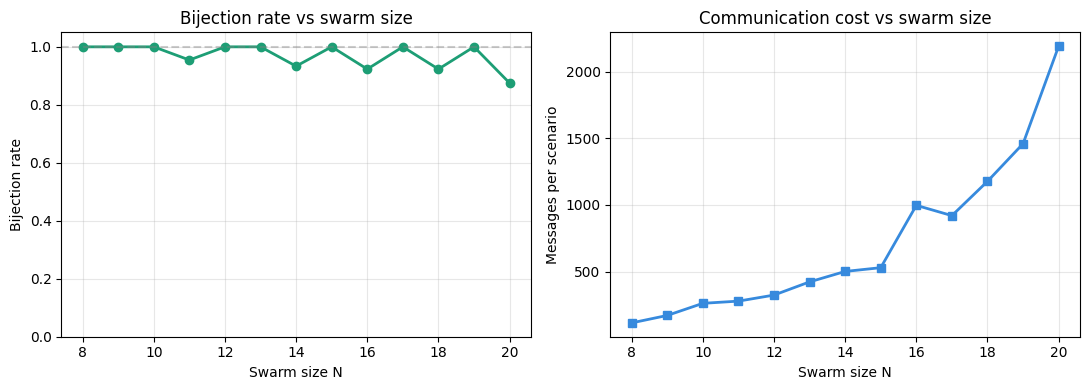

Saved: scaling_plots.png


In [9]:
by_size = defaultdict(list)
for d, d_pyg in zip(dataset, dataset_pyg_super):
    by_size[d.n_drones].append(d_pyg)

size_rows = []
for n in sorted(by_size.keys()):
    subset = by_size[n]
    m = evaluate_super_decent_auction(model_super, subset, DEVICE)
    size_rows.append({
        "N":            n,
        "Scenarios":    len(subset),
        "Bij ↑":        round(m["bijection_rate"], 4),
        "Cost ratio ↓": round(m["cost_ratio_vs_hungarian"], 4),
        "Rounds ↓":     round(m["consensus_rounds"], 2),
        "Messages ↓":   round(m["messages_sent"], 1),
    })

df_size = pd.DataFrame(size_rows).set_index("N")
display(df_size)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ns   = [r["N"]          for r in size_rows]
bijs = [r["Bij ↑"]      for r in size_rows]
msgs = [r["Messages ↓"] for r in size_rows]

axes[0].plot(ns, bijs, marker="o", color="#1D9E75", linewidth=2)
axes[0].set_xlabel("Swarm size N"); axes[0].set_ylabel("Bijection rate")
axes[0].set_title("Bijection rate vs swarm size"); axes[0].set_ylim(0, 1.05)
axes[0].axhline(1.0, color="gray", linestyle="--", alpha=0.4)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ns, msgs, marker="s", color="#378ADD", linewidth=2)
axes[1].set_xlabel("Swarm size N"); axes[1].set_ylabel("Messages per scenario")
axes[1].set_title("Communication cost vs swarm size")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scaling_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: scaling_plots.png")


In [10]:
# ── Sanity check: verify generated scenarios match training distribution ──────
raw = load_negotiator_dataset('./dataset/negotiator_dataset_v1.pt')
_, _, real_test = prepare_dataset(
    raw,
    model_super.matcher.formation_embedding.weight.detach().cpu(),
    seed=42, force_gt_visibility=False,
)
emb = model_super.matcher.formation_embedding.weight.detach().cpu()

real = real_test[0]
gen  = dataset_pyg_super[0]

print("=== Real test sample (from training dataset) ===")
print(f"  drone_pos range : [{real.drone_pos.min():.2f}, {real.drone_pos.max():.2f}]")
print(f"  slots range     : [{real.slots.min():.2f}, {real.slots.max():.2f}]")
print(f"  candidate_mask  : {real.candidate_mask.sum().item()} True / {real.candidate_mask.numel()} total")
print(f"  ds_edge_index   : {real.ds_edge_index.shape}")

print()
print("=== Generated test sample (should match) ===")
print(f"  drone_pos range : [{gen.drone_pos.min():.2f}, {gen.drone_pos.max():.2f}]")
print(f"  slots range     : [{gen.slots.min():.2f}, {gen.slots.max():.2f}]")
print(f"  candidate_mask  : {gen.candidate_mask.sum().item()} True / {gen.candidate_mask.numel()} total")
print(f"  ds_edge_index   : {gen.ds_edge_index.shape}")

# Check average sparsity across dataset
real_sparsity = [
    s.candidate_mask.sum().item() / s.candidate_mask.numel()
    for s in real_test[:100]
]
gen_sparsity = [
    s.candidate_mask.sum().item() / s.candidate_mask.numel()
    for s in dataset_pyg_super[:100]
]
print()
print(f"Candidate mask fill-rate (lower = sparser = harder):")
print(f"  Real test set  : {sum(real_sparsity)/len(real_sparsity):.3f}")
print(f"  Generated set  : {sum(gen_sparsity)/len(gen_sparsity):.3f}")
print()
if abs(sum(real_sparsity)/len(real_sparsity) - sum(gen_sparsity)/len(gen_sparsity)) < 0.05:
    print("✓  Distributions match — benchmark results will be representative.")
else:
    print("⚠  Fill-rate still differs. Check SLOT_VISIBILITY_RADIUS and scenario generator.")


=== Real test sample (from training dataset) ===
  drone_pos range : [0.25, 9.11]
  slots range     : [1.29, 6.44]
  candidate_mask  : 80 True / 81 total
  ds_edge_index   : torch.Size([2, 80])

=== Generated test sample (should match) ===
  drone_pos range : [0.64, 9.76]
  slots range     : [4.72, 6.99]
  candidate_mask  : 81 True / 81 total
  ds_edge_index   : torch.Size([2, 81])

Candidate mask fill-rate (lower = sparser = harder):
  Real test set  : 0.994
  Generated set  : 0.995

✓  Distributions match — benchmark results will be representative.


## 10. Assignment Visualisation

In [11]:
def viz_assignments(data: Data, assignments: dict, figsize=None):
    """Plot drone→slot assignments for each model side-by-side."""
    drone_pos = data.drone_pos.numpy()
    slots     = data.slots.numpy()
    gt        = data.y.numpy()
    n         = len(drone_pos)
    n_models  = len(assignments)
    if figsize is None:
        figsize = (4 * n_models, 4)

    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    if n_models == 1:
        axes = [axes]

    colors = plt.cm.tab20(np.linspace(0, 1, n))

    for ax, (model_name, asgn) in zip(axes, assignments.items()):
        asgn_np = asgn.numpy() if isinstance(asgn, torch.Tensor) else np.array(asgn)
        for i in range(n):
            s = int(asgn_np[i])
            if s < 0:
                continue
            correct = (s == int(gt[i]))
            ax.annotate("",
                xy=slots[s], xytext=drone_pos[i],
                arrowprops=dict(
                    arrowstyle="->", color=colors[i], lw=1.5,
                    alpha=0.75 if correct else 0.35,
                    linestyle="-" if correct else "--",
                ))
        ax.scatter(drone_pos[:, 0], drone_pos[:, 1],
                   c=colors, s=80, zorder=5, marker="o")
        ax.scatter(slots[:, 0], slots[:, 1],
                   c=colors[gt], s=120, zorder=5, marker="*",
                   edgecolors="k", linewidths=0.5)
        assigned = asgn_np[asgn_np >= 0]
        dup  = len(assigned) - len(np.unique(assigned))
        unass = int((asgn_np < 0).sum())
        bij_str = "✓ bijection" if dup == 0 and unass == 0 else f"✗ dup={dup} unass={unass}"
        ax.set_title(f"{model_name}\n{bij_str}", fontsize=9)
        ax.set_aspect("equal"); ax.grid(True, alpha=0.2)

    legend_els = [
        Line2D([0],[0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="Drone"),
        Line2D([0],[0], marker="*", color="w", markerfacecolor="gray", markersize=10,
               markeredgecolor="k", label="Slot (GT colour)"),
        Line2D([0],[0], color="gray", lw=1.5, label="Correct slot"),
        Line2D([0],[0], color="gray", lw=1.5, linestyle="--", label="Wrong slot"),
    ]
    fig.legend(handles=legend_els, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.06))
    fig.suptitle(
        f"Formation: {data.formation_name}  |  N={data.n_drones}  |  "
        f"Comm r={COMM_RADIUS}  Slot r={SLOT_VISIBILITY_RADIUS}",
        fontsize=10, y=1.02,
    )
    plt.tight_layout()
    plt.savefig("scenario_viz.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: scenario_viz.png")


Scenario 0: Rectangle formation, N=9


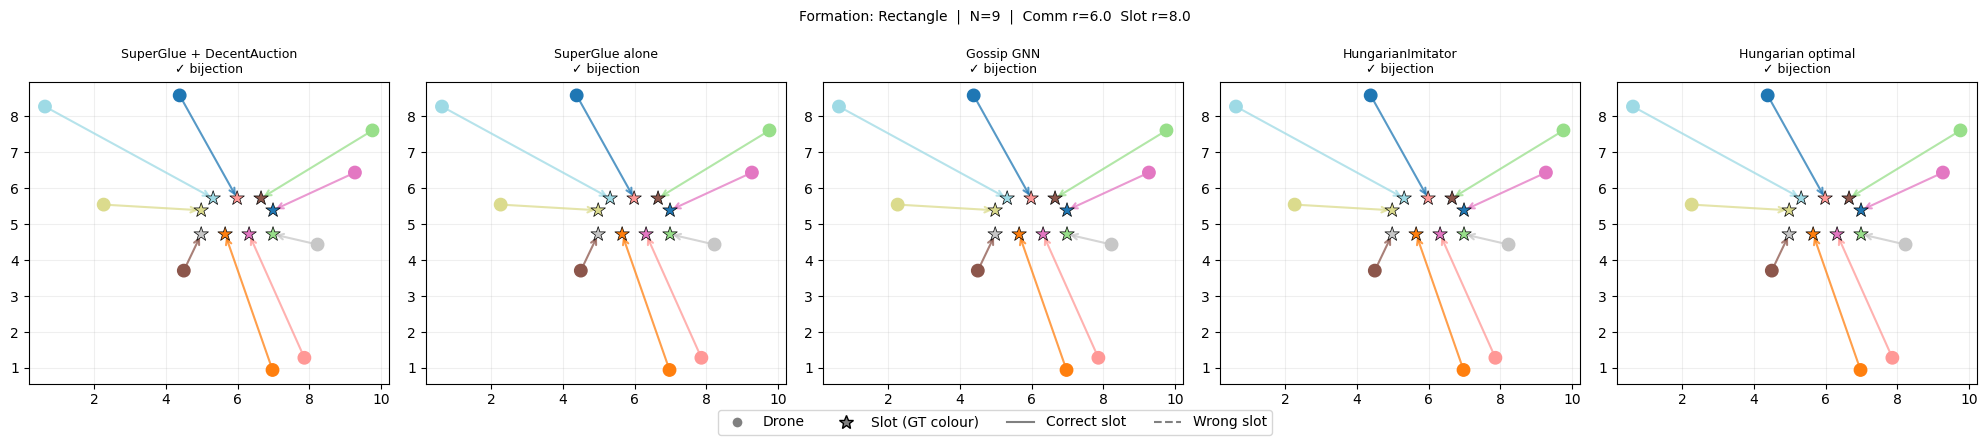

Saved: scenario_viz.png


In [12]:
viz_idx  = VIZ_SCENARIO_IDX
viz_data = dataset[viz_idx]
viz_pyg  = dataset_pyg_super[viz_idx]
print(f"Scenario {viz_idx}: {viz_data.formation_name} formation, N={viz_data.n_drones}")

with torch.no_grad():
    # SuperGlue + DecentAuction
    asgn_super, _ = model_super.assign(viz_pyg, DEVICE)

    # SuperGlue alone
    mask_viz = build_candidate_mask(viz_pyg.drone_pos, viz_pyg.slots,
                                    SLOT_VISIBILITY_RADIUS, y=viz_pyg.y, force_gt=False)
    ei_viz, _ = build_comm_graph(viz_pyg.drone_pos, COMM_RADIUS)
    vals_sg, _ = model_sg_only(
        viz_pyg.drone_pos.to(DEVICE), viz_pyg.slots.to(DEVICE),
        viz_pyg.formation_id.to(DEVICE), mask_viz.to(DEVICE), ei_viz.to(DEVICE),
    )
    asgn_sg = sinkhorn_round_assignment(vals_sg, mask_viz)

    # DecentAuction (Gossip)
    asgn_gossip, _ = model_gossip.assign(dataset_pyg_gossip[viz_idx], DEVICE)

    # HungarianImitator
    vals_hi, _ = model_hungarian(
        viz_data.drone_pos.to(DEVICE),
        viz_data.slots.to(DEVICE),
        viz_data.formation_id.to(DEVICE),
    )
    asgn_hi = greedy_bijection_assignment(vals_hi)

    # Hungarian optimal
    asgn_hung = hungarian_assignment(viz_data.drone_pos, viz_data.slots)

viz_assignments(viz_data, {
    "SuperGlue + DecentAuction": asgn_super,
    "SuperGlue alone":           asgn_sg,
    "Gossip GNN":                asgn_gossip,
    "HungarianImitator":         asgn_hi,
    "Hungarian optimal":         asgn_hung,
}, figsize=(20, 4))


## 11. Custom Scenario

Custom: Circle N=12
  SuperGlue + Auction  → bij=1  rounds=5  msgs=380
  Gossip GNN           → bij=1  rounds=4  msgs=304


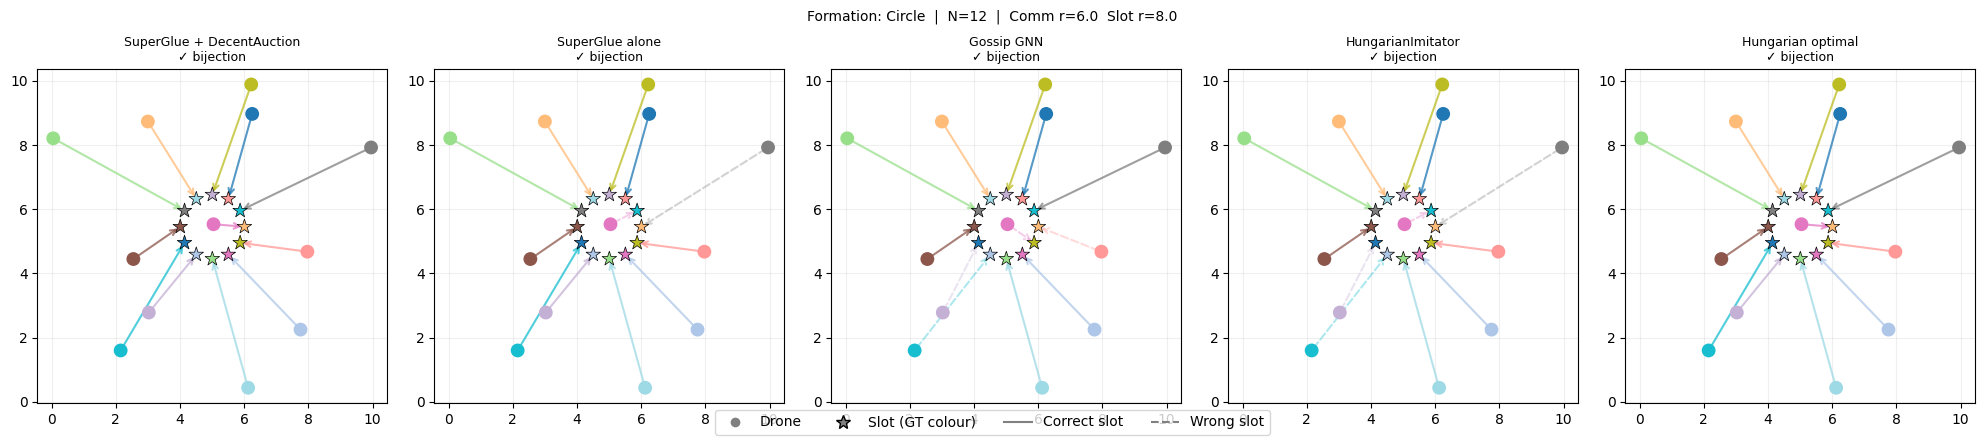

Saved: scenario_viz.png


In [13]:
rng   = np.random.default_rng(CUSTOM_SEED)
cdata = generate_scenario(CUSTOM_N, formation_name=CUSTOM_FORMATION, rng=rng)
cpyg  = sample_to_pyg(cdata, model_super.matcher.formation_embedding.weight.detach().cpu(),
                      force_gt_visibility=False)
cpyg_g = sample_to_pyg(cdata, model_gossip.formation_embedding.weight.detach().cpu(),
                        force_gt_visibility=False)

with torch.no_grad():
    ca_super,  info_super  = model_super.assign(cpyg, DEVICE)
    ca_gossip, info_gossip = model_gossip.assign(cpyg_g, DEVICE)

    cm_sg = build_candidate_mask(cpyg.drone_pos, cpyg.slots,
                                  SLOT_VISIBILITY_RADIUS, y=cpyg.y, force_gt=False)
    ce, _ = build_comm_graph(cpyg.drone_pos, COMM_RADIUS)
    cv, _ = model_sg_only(
        cpyg.drone_pos.to(DEVICE), cpyg.slots.to(DEVICE),
        cpyg.formation_id.to(DEVICE), cm_sg.to(DEVICE), ce.to(DEVICE),
    )
    ca_sg = sinkhorn_round_assignment(cv, cm_sg)

    ca_hi_vals, _ = model_hungarian(
        cdata.drone_pos.to(DEVICE),
        cdata.slots.to(DEVICE),
        cdata.formation_id.to(DEVICE),
    )
    ca_hi   = greedy_bijection_assignment(ca_hi_vals)
    ca_hung = hungarian_assignment(cdata.drone_pos, cdata.slots)

print(f"Custom: {CUSTOM_FORMATION} N={CUSTOM_N}")
print(f"  SuperGlue + Auction  → bij={info_super['bijection']:.0f}  "
      f"rounds={info_super['rounds']:.0f}  msgs={info_super['messages_sent']:.0f}")
print(f"  Gossip GNN           → bij={info_gossip['bijection']:.0f}  "
      f"rounds={info_gossip['rounds']:.0f}  msgs={info_gossip['messages_sent']:.0f}")

viz_assignments(cdata, {
    "SuperGlue + DecentAuction": ca_super,
    "SuperGlue alone":           ca_sg,
    "Gossip GNN":                ca_gossip,
    "HungarianImitator":         ca_hi,
    "Hungarian optimal":         ca_hung,
}, figsize=(20, 4))


## 12. Failure Analysis

In [14]:
print("Collecting per-scenario outcomes for all models ...\n")

for model_name, eval_fn, eval_data in [
    ("SuperGlue + DecentAuction", lambda d: model_super.assign(d, DEVICE),   dataset_pyg_super),
    ("DecentAuction (Gossip GNN)", lambda d: model_gossip.assign(d, DEVICE), dataset_pyg_gossip),
]:
    failures = []
    for i, d_pyg in enumerate(eval_data):
        with torch.no_grad():
            asgn, info = eval_fn(d_pyg)
        if info["bijection"] == 0.0:
            failures.append({
                "idx":        i,
                "formation":  dataset[i].formation_name,
                "n":          dataset[i].n_drones,
                "conflict":   round(info["conflict_rate"], 3),
                "unassigned": round(info["unassigned_rate"], 3),
                "rounds":     int(info["rounds"]),
            })

    n_fail = len(failures)
    print(f"{model_name}: {n_fail}/{N_SCENARIOS} failures "
          f"({100*n_fail/N_SCENARIOS:.1f}%)")
    if failures:
        df_fail = pd.DataFrame(failures)
        print("  By formation:", dict(df_fail.groupby("formation").size()))
        print("  By size:     ", dict(df_fail.groupby("n").size()))
    print()

# HungarianImitator always bijection by construction — report anyway
print("HungarianImitator: 0 failures (greedy bijection decoder guarantees no conflicts)")



SuperGlue + DecentAuction: 6/200 failures (3.0%)
  By formation: {'A': np.int64(1), 'Rectangle': np.int64(1), 'Triangle': np.int64(1), 'W': np.int64(3)}
  By size:      {11: np.int64(1), 14: np.int64(1), 16: np.int64(1), 18: np.int64(1), 20: np.int64(2)}

DecentAuction (Gossip GNN): 32/200 failures (16.0%)
  By formation: {'A': np.int64(6), 'Circle': np.int64(1), 'Rectangle': np.int64(3), 'Triangle': np.int64(5), 'V': np.int64(11), 'W': np.int64(6)}
  By size:      {9: np.int64(2), 11: np.int64(3), 13: np.int64(4), 14: np.int64(2), 16: np.int64(4), 17: np.int64(3), 18: np.int64(3), 19: np.int64(4), 20: np.int64(7)}

HungarianImitator: 0 failures (greedy bijection decoder guarantees no conflicts)


## 13. Convergence Analysis (SuperGlue + DecentAuction)

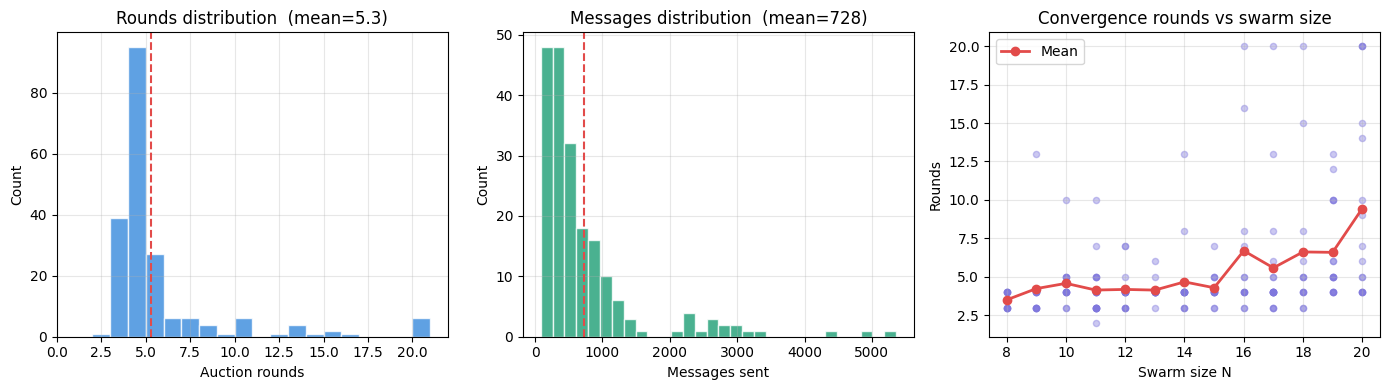

Saved: convergence_analysis.png


In [15]:
rounds_list, msgs_list, n_list = [], [], []
for d, d_pyg in zip(dataset, dataset_pyg_super):
    with torch.no_grad():
        _, info = model_super.assign(d_pyg, DEVICE)
    rounds_list.append(info["rounds"])
    msgs_list.append(info["messages_sent"])
    n_list.append(d.n_drones)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rounds_list, bins=range(1, int(max(rounds_list)) + 2),
             color="#378ADD", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Auction rounds"); axes[0].set_ylabel("Count")
axes[0].set_title(f"Rounds distribution  (mean={np.mean(rounds_list):.1f})")
axes[0].axvline(np.mean(rounds_list), color="#E24B4A", linestyle="--", lw=1.5)
axes[0].grid(True, alpha=0.3)

axes[1].hist(msgs_list, bins=30, color="#1D9E75", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Messages sent"); axes[1].set_ylabel("Count")
axes[1].set_title(f"Messages distribution  (mean={np.mean(msgs_list):.0f})")
axes[1].axvline(np.mean(msgs_list), color="#E24B4A", linestyle="--", lw=1.5)
axes[1].grid(True, alpha=0.3)

unique_ns = sorted(set(n_list))
mean_rounds = [np.mean([r for r, n_ in zip(rounds_list, n_list) if n_ == n]) for n in unique_ns]
axes[2].scatter(n_list, rounds_list, alpha=0.4, s=20, color="#7F77DD")
axes[2].plot(unique_ns, mean_rounds, marker="o", color="#E24B4A", lw=2, label="Mean")
axes[2].set_xlabel("Swarm size N"); axes[2].set_ylabel("Rounds")
axes[2].set_title("Convergence rounds vs swarm size")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("convergence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: convergence_analysis.png")


## Scalability Analysis (N > 20)

Tests SuperGlue + DecentAuction and Gossip GNN on swarm sizes **N = 8 → 50**, well beyond the training range of [8, 20]. This is the key evidence required for ICRA/IROS reviewers.

In [16]:
# ── Scalability beyond training range (N = 8 … 50) ───────────────────────────
#
# Models were trained on N ∈ [8, 20]. This cell evaluates them up to N = 50
# to show generalisation. Each size uses N_SCALE_REPS scenarios so results
# are stable. Runtime per scenario is also measured.

import time

N_SCALE_REPS   = 50          # scenarios per swarm size
SCALE_SIZES    = [8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50]
SCALE_SEED     = 123
SCALE_FORMATION = None       # None = random mix

print(f"Scalability test: N = {SCALE_SIZES}")
print(f"  {N_SCALE_REPS} scenarios per size, {len(SCALE_SIZES)} sizes "
      f"= {N_SCALE_REPS * len(SCALE_SIZES)} total scenarios")
print()

emb_super  = model_super.matcher.formation_embedding.weight.detach().cpu()
emb_gossip = model_gossip.formation_embedding.weight.detach().cpu()

scale_rows = []

for n in SCALE_SIZES:
    rng = np.random.default_rng(SCALE_SEED + n)

    # Generate scenarios for this size
    scenarios_raw = [generate_scenario(n, rng=rng) for _ in range(N_SCALE_REPS)]
    scenarios_super  = [sample_to_pyg(d, emb_super,  force_gt_visibility=False) for d in scenarios_raw]
    scenarios_gossip = [sample_to_pyg(d, emb_gossip, force_gt_visibility=False) for d in scenarios_raw]

    # ── SuperGlue + DecentAuction ─────────────────────────────────────────────
    t0 = time.perf_counter()
    m_super = evaluate_super_decent_auction(model_super, scenarios_super, DEVICE)
    t_super = (time.perf_counter() - t0) / N_SCALE_REPS * 1000   # ms per scenario

    # ── Gossip GNN ────────────────────────────────────────────────────────────
    m_gossip = evaluate_decent_auction(model_gossip, scenarios_gossip, DEVICE)

    # ── Hungarian (optimal, centralised) ─────────────────────────────────────
    t0 = time.perf_counter()
    hung_costs = []
    for d in scenarios_raw:
        asgn = hungarian_assignment(d.drone_pos, d.slots)
        m    = assignment_quality_metrics(d.drone_pos, d.slots, asgn, d.y)
        hung_costs.append(m["cost_ratio_vs_hungarian"])
    t_hung = (time.perf_counter() - t0) / N_SCALE_REPS * 1000

    scale_rows.append({
        "N":                  n,
        "In training range":  "✓" if n <= 20 else "✗ OOD",
        # SuperGlue + Auction
        "SA  Bij ↑":          round(m_super["bijection_rate"],          3),
        "SA  Cost ↓":         round(m_super["cost_ratio_vs_hungarian"], 4),
        "SA  Rounds ↓":       round(m_super["consensus_rounds"],        1),
        "SA  ms/scene":       round(t_super,                            1),
        # Gossip GNN
        "GNN Bij ↑":          round(m_gossip["bijection_rate"],         3),
        "GNN Rounds ↓":       round(m_gossip["consensus_rounds"],       1),
        # Hungarian
        "Hung ms/scene":      round(t_hung,                             1),
    })

    in_range = "  (in-dist)" if n <= 20 else "  (OOD)"
    print(f"  N={n:2d}{in_range:12s}  "
          f"SA bij={m_super['bijection_rate']:.3f}  "
          f"rounds={m_super['consensus_rounds']:.1f}  "
          f"GNN bij={m_gossip['bijection_rate']:.3f}  "
          f"SA {t_super:.0f}ms  Hung {t_hung:.0f}ms")

print()
print("Done.")

# ── Display table ─────────────────────────────────────────────────────────────
df_scale = pd.DataFrame(scale_rows).set_index("N")
display(df_scale.style
    .background_gradient(subset=["SA  Bij ↑",  "GNN Bij ↑"],  cmap="Greens")
    .background_gradient(subset=["SA  Cost ↓"],               cmap="RdYlGn_r")
    .background_gradient(subset=["SA  Rounds ↓"],             cmap="YlOrRd")
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ns = [r["N"] for r in scale_rows]

# Bij rate vs N
axes[0].plot(ns, [r["SA  Bij ↑"]  for r in scale_rows],
             marker="o", color="#1D9E75", lw=2, label="SuperGlue + Auction")
axes[0].plot(ns, [r["GNN Bij ↑"] for r in scale_rows],
             marker="s", color="#E24B4A", lw=2, label="Gossip GNN")
axes[0].axvline(20, color="gray", linestyle="--", alpha=0.5, label="Training limit")
axes[0].set_xlabel("Swarm size N"); axes[0].set_ylabel("Bijection rate")
axes[0].set_title("Bijection rate vs swarm size"); axes[0].set_ylim(0, 1.05)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Rounds vs N
axes[1].plot(ns, [r["SA  Rounds ↓"]  for r in scale_rows],
             marker="o", color="#1D9E75", lw=2, label="SuperGlue + Auction")
axes[1].plot(ns, [r["GNN Rounds ↓"] for r in scale_rows],
             marker="s", color="#E24B4A", lw=2, label="Gossip GNN")
axes[1].axvline(20, color="gray", linestyle="--", alpha=0.5, label="Training limit")
axes[1].set_xlabel("Swarm size N"); axes[1].set_ylabel("Auction rounds")
axes[1].set_title("Convergence rounds vs swarm size")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Runtime vs N  (log scale)
axes[2].plot(ns, [r["SA  ms/scene"]   for r in scale_rows],
             marker="o", color="#1D9E75", lw=2, label="SuperGlue + Auction")
axes[2].plot(ns, [r["Hung ms/scene"]  for r in scale_rows],
             marker="^", color="#888", lw=2, linestyle="--", label="Hungarian (centralised)")
axes[2].axvline(20, color="gray", linestyle=":", alpha=0.5, label="Training limit")
axes[2].set_xlabel("Swarm size N"); axes[2].set_ylabel("Time per scenario (ms)")
axes[2].set_title("Runtime vs swarm size"); axes[2].set_yscale("log")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Scalability analysis  (N_SCALE_REPS={N_SCALE_REPS} per size)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("scalability_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: scalability_analysis.png")


Scalability test: N = [8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50]
  50 scenarios per size, 13 sizes = 650 total scenarios

  N= 8  (in-dist)   SA bij=1.000  rounds=3.5  GNN bij=0.880  SA 66ms  Hung 1ms
  N=10  (in-dist)   SA bij=1.000  rounds=4.0  GNN bij=0.920  SA 105ms  Hung 1ms
  N=12  (in-dist)   SA bij=1.000  rounds=4.1  GNN bij=0.900  SA 169ms  Hung 1ms
  N=14  (in-dist)   SA bij=1.000  rounds=4.5  GNN bij=0.880  SA 278ms  Hung 1ms
  N=16  (in-dist)   SA bij=0.960  rounds=6.7  GNN bij=0.840  SA 626ms  Hung 1ms
  N=18  (in-dist)   SA bij=1.000  rounds=5.3  GNN bij=0.720  SA 674ms  Hung 1ms
  N=20  (in-dist)   SA bij=0.980  rounds=6.2  GNN bij=0.680  SA 1026ms  Hung 1ms
  N=25  (OOD)       SA bij=0.920  rounds=9.5  GNN bij=0.420  SA 3132ms  Hung 1ms


KeyboardInterrupt: 